# Chapter 6 — Use Cases

## Operational demonstrations of the tb-scouting framework

This notebook illustrates how the framework introduced in the previous chapters can be operationalised on real scouting questions. Four representative use cases are presented, each combining the role-matching engine (`src.matching`) with the visualisation layer (`src.visualisation`):

1. **Finding ball-playing centre-backs** — talent identification for a possession-based system.
2. **Finding pressing forwards** — talent identification for a high-press style.
3. **Player profiling** — characterising the natural role of Luka Modrić.
4. **Similarity search** — retrieving the closest stylistic neighbours of Marco Verratti.

All metrics are derived from StatsBomb open event data for the 2015/16 season of the five major European leagues (La Liga, Premier League, Bundesliga, Ligue 1, Serie A). Players are filtered at a minimum of 450 minutes played. All visualisations are exported as PNG (300 DPI) to `C:/tb-scouting/results/`.

## Setup

In [1]:
import sys
import os

# Ensure the project root is on the import path so that `src.*` is reachable
PROJECT_ROOT = 'C:/tb-scouting'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import matplotlib.pyplot as plt

from src.matching import (
    rank_players_by_role,
    find_similar_players,
    profile_player,
)
from src.visualisation import (
    plot_radar_chart,
    plot_ranking_table,
    plot_pca_scatter,
    plot_player_card,
)

RESULTS_DIR = 'C:/tb-scouting/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Display options for clean tabular output
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Results directory: {RESULTS_DIR}')

Project root: C:/tb-scouting
Results directory: C:/tb-scouting/results


---

## Use case 1 — Finding ball-playing centre-backs

**Scouting brief.** A coach setting up a possession-based 4-3-3 with a build-up out of the back requires a centre-back who is comfortable in tight spaces, distributes accurately under pressure, and contributes to ball progression rather than merely clearing the lines. The tactical literature labels this profile a *Ball-Playing Defender* (BPD), defined in our role taxonomy by high weights on progressive passing, completion rate, progressive carries, passes into the final third, and ball-progression metrics — while still retaining baseline defensive solidity.

**Method.** We score every centre-back (`position_group = 'CB'`, minutes ≥ 450) against the `ball_playing_defender` profile from `config/role_profiles.yaml`. The score is a weighted cosine similarity between the player's MinMax-normalised metric vector and the 90th-percentile reference vector of the CB population — bounded in [0, 100]. The ranking table is rendered as a calibrated visual, and the top-ranked candidate is then drilled into via a radar chart that contrasts his per-90 profile with the ideal.

In [2]:
# Score every CB against the ball-playing-defender profile
uc1_ranking = rank_players_by_role(
    role_name='ball_playing_defender',
    position='CB',
    min_minutes=450,
    top=10,
    verbose=False,
)
uc1_ranking.head(10)

,player_name,team,minutes_total,score,cluster,role_label
0,Fallou Diagne,Rennes,1874.60,99.65,2,CB-2
1,Mickaël Tacalfred,Stade de Reims,1176.52,99.52,3,CB-3
2,Florentin Pogba,Saint-Étienne,1876.02,99.37,2,CB-2
3,Nicolas Pallois,Bordeaux,1471.73,99.35,3,CB-3
4,Álvaro González Soberón,Espanyol,3246.42,99.30,2,CB-2
5,Aythami Artiles Oliva,Las Palmas,2645.63,99.29,2,CB-2
6,Sylvain Armand,Rennes,3013.83,99.28,2,CB-2
7,Timm Klose,Wolfsburg,1496.93,99.28,2,CB-2
8,Ashley Williams,Swansea City,3289.10,99.27,2,CB-2
9,Marcelo Antônio Guedes Filho,Hannover 96,1706.18,99.26,2,CB-2


[saved] C:/tb-scouting\results\uc1_ranking_bpd.png


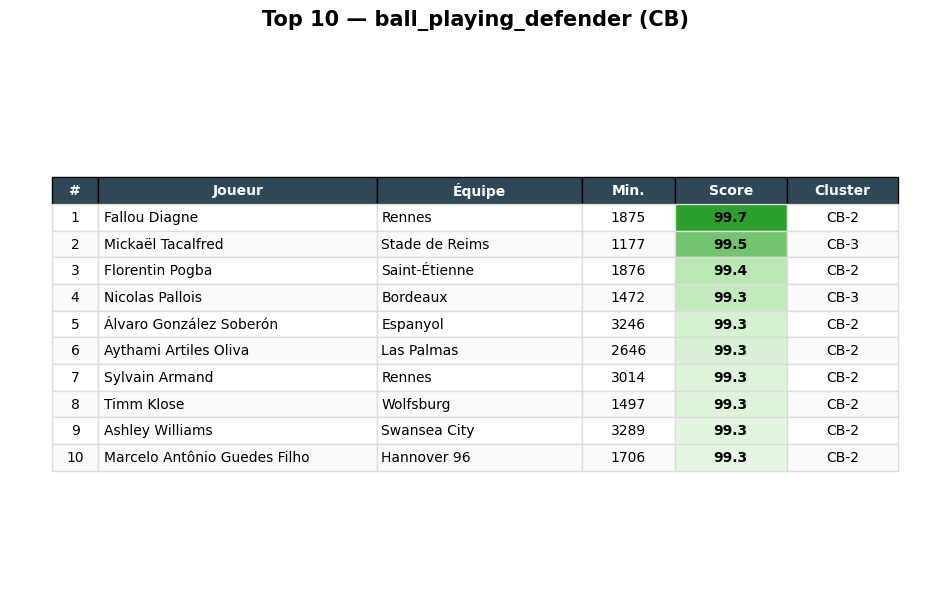

In [3]:
# Visualise the top 10 as a ranking table
fig = plot_ranking_table(
    role_name='ball_playing_defender',
    position='CB',
    top_n=10,
    save_path='uc1_ranking_bpd.png',
)
plt.show()

Top-ranked ball-playing defender: Fallou Diagne


[saved] C:/tb-scouting\results\uc1_radar_bpd_top1.png


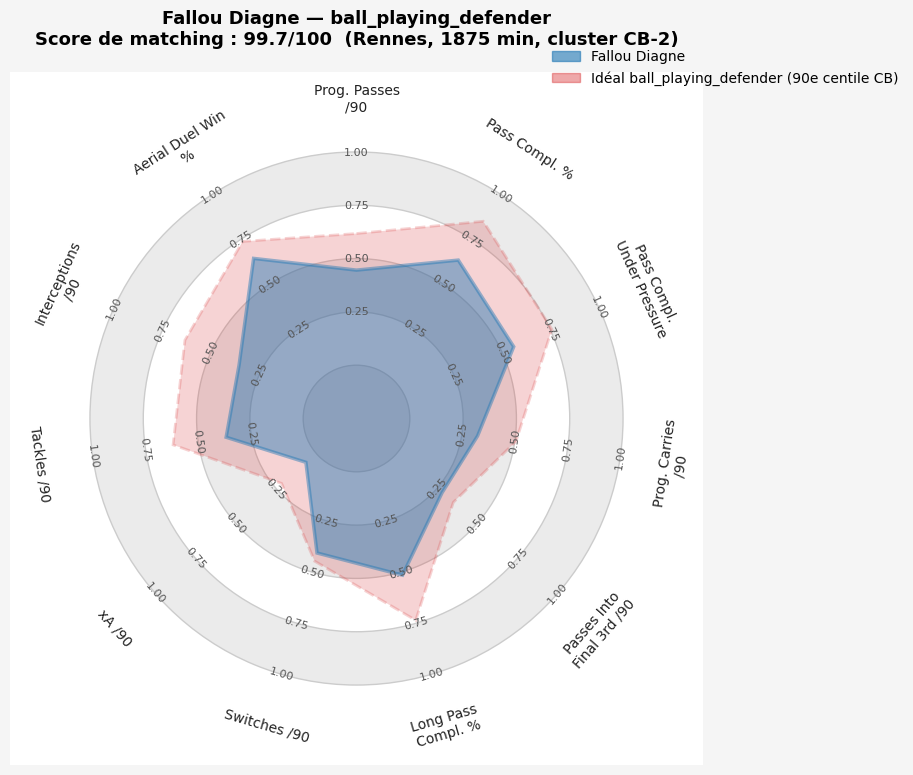

In [4]:
# Drill into the #1 candidate with a radar chart against the ideal profile
top1_name = uc1_ranking.iloc[0]['player_name']
print(f'Top-ranked ball-playing defender: {top1_name}')

fig = plot_radar_chart(
    player_name=top1_name,
    role_name='ball_playing_defender',
    position='CB',
    save_path='uc1_radar_bpd_top1.png',
)
plt.show()

**Reading.** The top of the ranking should populate with centre-backs known for elite progressive distribution — typically La Liga and Bundesliga profiles whose teams play from the back. The radar reveals *where* the candidate matches the BPD template (large overlapping blue and red regions on passing and progression axes) versus *where* he merely meets baseline expectations (defensive duel and aerial axes). The strengths/weaknesses lines in the ranking output further indicate, for each player, the specific metrics on which he over- or under-shoots the 90th-percentile reference — providing the analyst with an interpretable explanation rather than an opaque score.

---

## Use case 2 — Finding pressing forwards

**Scouting brief.** A high-pressing 4-3-3 (Klopp/Nagelsmann-style) hinges on a centre-forward willing to lead the first pressure on the opposition build-up. The *Pressing Forward* archetype combines a very high pressure volume, a strong pressure success rate (i.e., pressures that actually trigger a recovery within five seconds), recovery actions, and a baseline finishing ability — finishing is secondary to defensive workload from the front.

**Method.** Identical pipeline as use case 1, applied to the `pressing_forward` profile over the striker population (`position_group = 'ST'`, minutes ≥ 450). The role weights emphasise `pressures_p90`, `pressure_success_rate`, `recoveries_p90`, `tackles_p90` and `fouls_won_p90` — with reduced weight on shooting volume. This is a deliberately *defensive* striker profile, distinct from `advanced_forward` or `poacher`.

In [5]:
# Score every ST against the pressing-forward profile
uc2_ranking = rank_players_by_role(
    role_name='pressing_forward',
    position='ST',
    min_minutes=450,
    top=10,
    verbose=False,
)
uc2_ranking.head(10)

,player_name,team,minutes_total,score,cluster,role_label
0,Souleymane Camara,Montpellier,1991.73,99.43,2,ST-2
1,Youssef El-Arabi,Granada,2544.37,99.41,0,ST-0
2,John Tshibumbu,Gazélec Ajaccio,1078.32,99.39,0,ST-0
3,Grejohn Kyei,Stade de Reims,738.37,99.28,3,ST-3
4,Luciano Vietto,Atlético Madrid,966.98,99.13,3,ST-3
5,Mauricio Ricardo Pinilla Ferreira,Atalanta,1369.52,99.11,0,ST-0
6,Fernando José Torres Sanz,Atlético Madrid,1714.08,99.11,2,ST-2
7,Callum Wilson,AFC Bournemouth,795.00,99.08,2,ST-2
8,Alassane Pléa,OGC Nice,1405.60,99.07,3,ST-3
9,Lacina Traoré,AS Monaco,830.27,99.02,0,ST-0


[saved] C:/tb-scouting\results\uc2_ranking_pressing_forward.png


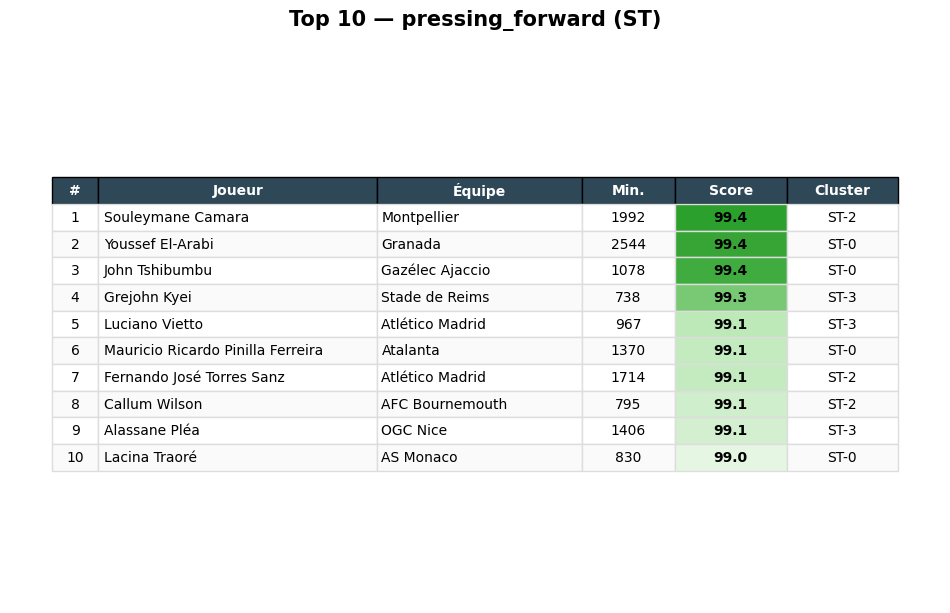

In [6]:
# Visualise the top 10 as a ranking table
fig = plot_ranking_table(
    role_name='pressing_forward',
    position='ST',
    top_n=10,
    save_path='uc2_ranking_pressing_forward.png',
)
plt.show()

Top-ranked pressing forward: Souleymane Camara


[saved] C:/tb-scouting\results\uc2_radar_pressing_forward_top1.png


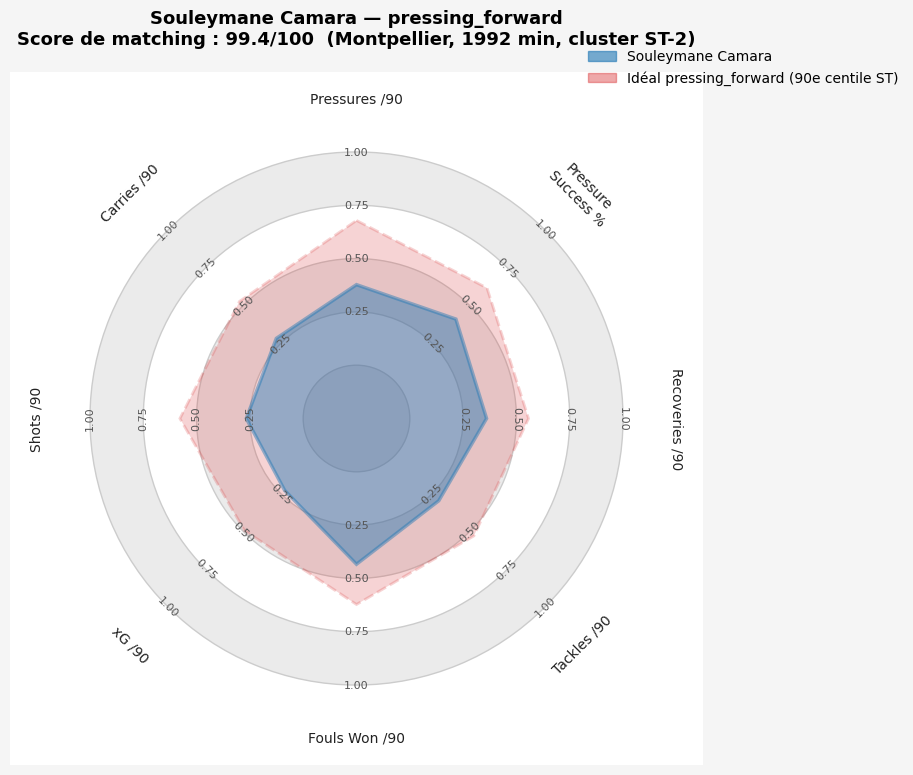

In [7]:
# Drill into the #1 candidate
top1_name = uc2_ranking.iloc[0]['player_name']
print(f'Top-ranked pressing forward: {top1_name}')

fig = plot_radar_chart(
    player_name=top1_name,
    role_name='pressing_forward',
    position='ST',
    save_path='uc2_radar_pressing_forward_top1.png',
)
plt.show()

**Reading.** The pressing-forward shortlist is expected to feature high-energy strikers from intensive-pressing teams — typically Bundesliga and Premier League forwards rather than finishers in possession-dominant sides. The radar chart highlights the defining duality of the role: an elite ceiling on the pressing and recovery axes, contrasted with intentionally moderate offensive output. Strikers who score highly here despite lower xG numbers should not be discounted — they would be a poor fit for the `poacher` role but a strong fit for the tactical brief at hand. This use case illustrates the value of role-conditioned scoring over a single global rating: the same player can be "weak" or "strong" depending on which template he is evaluated against.

---

## Use case 3 — Player profiling: what is Modrić's natural role?

**Analytical brief.** The previous use cases project the search direction *from a role onto a population*. Profiling reverses the direction: given a known player, *which of the predefined tactical roles does his statistical signature most closely match?* This is a diagnostic application — useful for tactical scouting reports, for evaluating whether a recruiting target would fit an existing role in the squad, or for confirming whether a player's empirical output aligns with the role he is nominally deployed in.

**Method.** For each role defined in `role_profiles.yaml` under the player's `position_group`, the same weighted cosine similarity is computed. The role with the highest score is declared the *natural role* — empirically the one his per-90 profile most closely resembles. The full ranking is also reported, since the second- and third-best roles are themselves informative about tactical flexibility. The player card visualises this together with strengths, weaknesses, and the closest stylistic neighbours.

In [8]:
# Full role profile of Modrić across all MF role templates
uc3_profile = profile_player('Modric', position='MF', verbose=True)
uc3_profile


=== Profil de "Luka Modrić" (Real Madrid, MF, 2634 min) ===
  deep_lying_playmaker           99.05  <-- rôle naturel
  mezzala                        98.04
  ball_winning_midfielder        93.06
  box_to_box_midfielder          91.02


,role_name,score,is_natural
0,deep_lying_playmaker,99.05,True
1,mezzala,98.04,False
2,ball_winning_midfielder,93.06,False
3,box_to_box_midfielder,91.02,False


Modric's natural role: deep_lying_playmaker


[saved] C:/tb-scouting\results\uc3_card_modric_natural.png


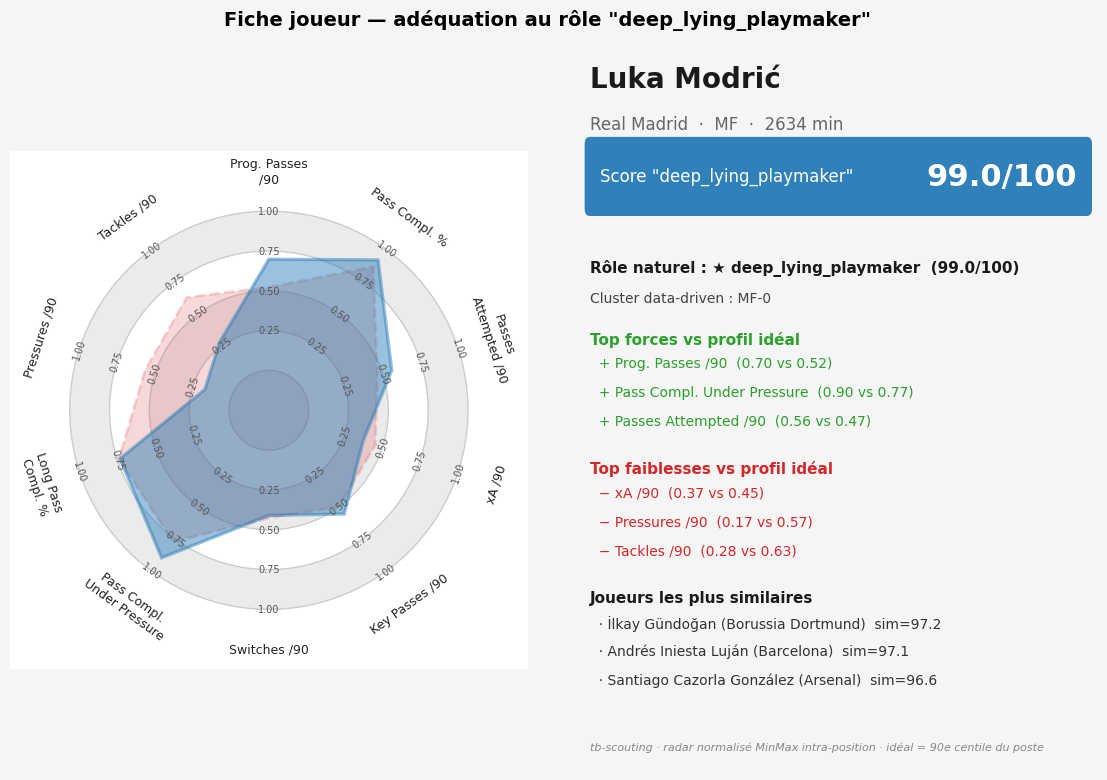

In [9]:
# Render the full player card against his natural (top-ranked) role
natural_role = uc3_profile.iloc[0]['role_name']
print(f"Modric's natural role: {natural_role}")

fig = plot_player_card(
    player_name='Modric',
    role_name=natural_role,
    position='MF',
    save_path='uc3_card_modric_natural.png',
)
plt.show()

**Reading.** Modrić's role profile distribution is itself the analytical artefact: a player whose top score is markedly higher than the rest is a *role-specialist*, whereas a player with several near-tied scores is *positionally versatile*. The player card consolidates all the diagnostic information in a single A4-landscape artefact suitable for inclusion in scouting dossiers: the radar visualises the alignment with the inferred natural role, while the right-hand panel surfaces the empirical evidence (cluster membership, top strengths, top weaknesses, and the three closest stylistic neighbours). The cluster label (data-driven, unsupervised) and the natural role (theory-driven, role-template-based) provide two independent perspectives that the analyst can triangulate.

---

## Use case 4 — Finding players similar to Verratti

**Scouting brief.** A frequent operational question in recruitment is the *replacement search*: identify players whose statistical signature most resembles a reference player. In this case the reference is Marco Verratti, a high-volume, press-resistant deep-lying midfielder. The objective is to surface alternative candidates with a comparable on-ball profile across the five major European leagues.

**Method.** Unlike the role-based scoring of use cases 1 and 2, similarity search uses the *full* metric vector of the reference player as the query. Each candidate's vector — MinMax-normalised within the same `position_group` — is compared via cosine similarity. The result is a role-agnostic ranking driven entirely by the data, with no tactical template imposed. The PCA scatter plot then localises Verratti within the two-dimensional projection of the MF population, with cluster membership colour-coded, allowing the analyst to see which region of the role-space the similar players inhabit.

In [10]:
# Top 10 players most similar to Verratti
uc4_similar = find_similar_players('Verratti', position='MF', top_n=10)
uc4_similar

,player_name,team,position_group,minutes_total,similarity,role_label
0,Jorge Luiz Frello Filho,Napoli,MF,2962.92,95.49,MF-0
1,Jean Michaël Seri,OGC Nice,MF,3145.02,92.56,MF-0
2,Xabier Alonso Olano,Bayern Munich,MF,1939.23,92.25,MF-0
3,Julian Weigl,Borussia Dortmund,MF,2247.83,91.98,MF-0
4,Jordan Ferri,Lyon,MF,2468.85,91.81,MF-0
5,Francesc Fàbregas i Soler,Chelsea,MF,2999.40,91.63,MF-0
6,İlkay Gündoğan,Borussia Dortmund,MF,1998.08,91.49,MF-0
7,Luka Modrić,Real Madrid,MF,2633.52,91.34,MF-0
8,João Filipe Iria Santos Moutinho,AS Monaco,MF,2174.57,91.32,MF-0
9,Borja Valero Iglesias,Fiorentina,MF,3163.53,91.28,MF-0


[saved] C:/tb-scouting\results\uc4_pca_verratti.png


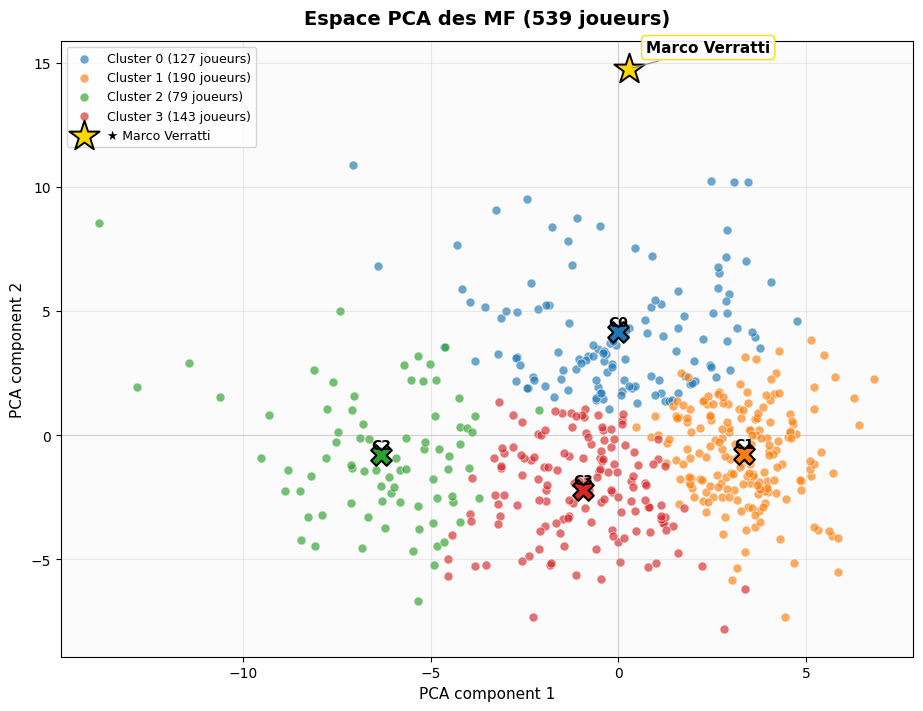

In [11]:
# Locate Verratti and his stylistic neighbours in PCA space
fig = plot_pca_scatter(
    position='MF',
    highlight_player='Verratti',
    save_path='uc4_pca_verratti.png',
)
plt.show()

**Reading.** The similarity ranking surfaces an analytically meaningful neighbourhood: the most similar players should belong predominantly to the same data-driven cluster as Verratti, validating the consistency of the framework. The PCA scatter confirms this visually — the gold star (Verratti) sits inside the cluster region populated by his nearest stylistic neighbours, distant from the centroids of the other clusters that capture more defensive or more advanced midfielder profiles. The combination of the ranked similarity table and the spatial visualisation provides both a deterministic shortlist ("these ten players are the closest matches") and a topological understanding ("this is the region of role-space he occupies").

---

## Closing remarks

The four use cases above demonstrate the operational utility of a unified pipeline that fuses (i) low-level event aggregation from StatsBomb, (ii) position-conditioned normalisation and unsupervised clustering, (iii) theory-driven role templates encoded in a YAML configuration, and (iv) visualisations suitable for inclusion in scouting reports.

The same atomic functions — `rank_players_by_role`, `find_similar_players`, `profile_player`, and their visual counterparts — can be recomposed to address any scouting brief that can be framed either as *find players matching a template* or as *find players resembling a reference*. Adding a new tactical role amounts to declaring its metric weights in the YAML; adding a new metric amounts to extending the feature-engineering stage in `src/features.py`. The framework is therefore extensible without requiring any change to the matching or visualisation logic — the principle of separation of concerns that underpins the design choices documented in chapters 3 to 5.